# 5. Carbon

Carbon is the element every other chapter is about, because it is the
electron donor for almost everything. Its redox range is the widest of any
biological element — methane at −IV to carbon dioxide at +IV — and the whole
of heterotrophic metabolism lives somewhere on that span.

This notebook is the template for the eight that follow: the ladder, what is
stable, where each form lives, and which organisms make a living on each
step. Every number is computed here, not quoted.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import (
    frost_diagram,
    latimer_diagram,
    plot_frost,
    plot_latimer,
    plot_pourbaix,
)

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder

A Latimer diagram is the element's oxidation states in a row with the
potential of each step on the arrow. Ours is computed at whatever pH you ask
for, which matters more for carbon than for most elements.

In [2]:
ladder = latimer_diagram("C", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,HCO3-,Formate(aq),2.0,-0.408326,78.795005,HCO3- + 2 H+ + 2 e- -> Formate(aq) + H2O
1,Formate(aq),Graphite,2.0,0.018708,-3.610008,Formate(aq) + 3 H+ + 2 e- -> Graphite + 2 H2O
2,Graphite,Methane(aq),4.0,-0.324850,125.373210,Graphite + 4 H+ + 4 e- -> Methane(aq)


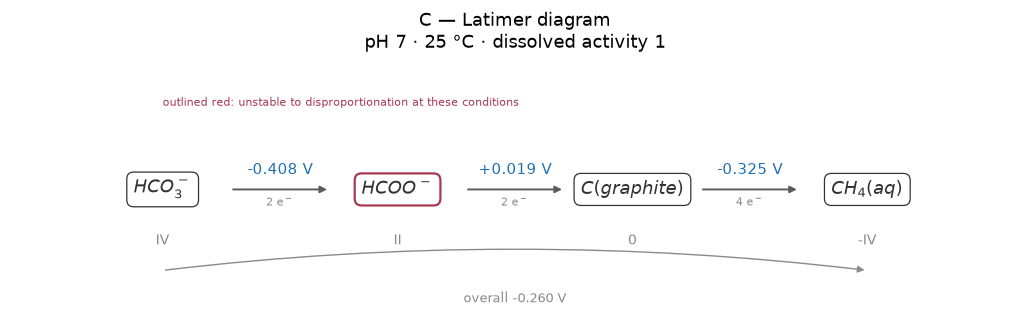

In [3]:
plot_latimer("C", diagram=ladder)
plt.show()

Two things in that table are worth stopping on.

The C(0) rung is **graphite**, and the species it beat is **acetate** —
both are carbon at oxidation state zero. The library picks whichever has the
lower free energy at the working pH and keeps the other in `.alternatives`:

In [4]:
ladder.alternatives

((4.0, 'CO2(aq)'), (4.0, 'CO3--'), (0.0, 'Acetate'))

For a biologist acetate is the interesting C(0) species, and saying so is a
one-line change. The zero of the diagram stays graphite either way, because
the element reference is chosen independently of which species you plot:

In [5]:
biological = latimer_diagram(
    "C",
    species=["HCO3-", "CO3--", "Formate(aq)", "Acetate", "Methane(aq)"],
    pH=7.0,
)
biological.to_frame()[["oxidized", "reduced", "n electrons", "E (V)"]]

,oxidized,reduced,n electrons,E (V)
0,HCO3-,Formate(aq),2.0,-0.408326
1,Formate(aq),Acetate,2.0,-0.149917
2,Acetate,Methane(aq),4.0,-0.240538


## pH moves it, and not gently

In [6]:
for ph in (0.0, 4.0, 7.0, 9.0):
    steps = latimer_diagram("C", pH=ph).steps
    chain = "  ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in steps)
    print(f"pH {ph:4.1f}   {chain}")

pH  0.0   CO2(aq) –(-0.182)→ Formate(aq)  Formate(aq) –(+0.640)→ Graphite  Graphite –(+0.089)→ Methane(aq)
pH  4.0   CO2(aq) –(-0.300)→ Formate(aq)  Formate(aq) –(+0.285)→ Graphite  Graphite –(-0.147)→ Methane(aq)
pH  7.0   HCO3- –(-0.408)→ Formate(aq)  Formate(aq) –(+0.019)→ Graphite  Graphite –(-0.325)→ Methane(aq)
pH  9.0   HCO3- –(-0.527)→ Formate(aq)  Formate(aq) –(-0.159)→ Graphite  Graphite –(-0.443)→ Methane(aq)


The top rung changes species — CO₂(aq) below the first p*K*a, bicarbonate
above it — and every potential drops as protons become scarcer. Carbon
dioxide reduction is easier in acid, which is one reason methanogens are not
fussy about it and acetogens are.

## What is stable: the Frost diagram

Volt equivalent against oxidation state. The slope between two points is the
potential of that couple; a point above the line joining two others is
unstable and will disproportionate; the lowest point is where carbon ends up.

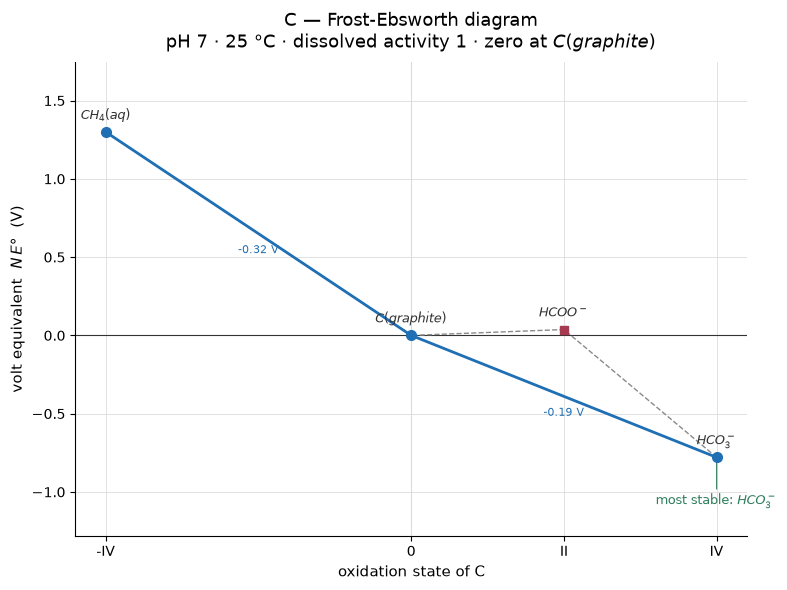

In [7]:
plot_frost("C", pH=7.0, annotate_slopes=True)
plt.show()

In [8]:
frost = frost_diagram("C", pH=7.0)
print("most stable form:", frost.most_stable.backend)
for event in frost.disproportionation():
    print(event)

most stable form: HCO3-
Formate(aq) -> 0.5 HCO3- + 0.5 Graphite  (-41.2 kJ/mol Formate(aq))


**Formate is thermodynamically doomed and completely ordinary.** The diagram
says it should fall apart into bicarbonate and elemental carbon, releasing
about 41 kJ per mole. Nothing of the sort happens in a bottle of formate on
the bench, because there is no mechanism: graphite does not nucleate out of
aqueous solution at 25 °C.

That is the most useful thing a Frost diagram teaches, and it is worth
stating plainly: **it is a statement about direction, not about rate.** Every
metastable intermediate in biogeochemistry — formate, nitrite, elemental
sulfur — is a species sitting above the hull with no way down.

### Showing every form, not just the one that predominates

By default each oxidation state contributes one point — the form with the
lowest energy at the working pH, which is the one that actually exists.
`predominant_only=False` keeps them all, and then two species can sit at the
same x: graphite and acetate at C(0), and all three carbonate forms at
C(+IV).

In [9]:
everything = frost_diagram("C", pH=7.0, predominant_only=False)
everything.to_frame()[["species", "oxidation state", "volt equivalent (V)", "on hull"]]

,species,oxidation state,volt equivalent (V),on hull
0,Methane(aq),-4.0,1.299402,True
1,Graphite,0.0,0.000000,True
2,Acetate,0.0,0.337249,False
3,Formate(aq),2.0,0.037415,False
4,HCO3-,4.0,-0.779238,True
5,CO2(aq),4.0,-0.740438,False
6,CO3--,4.0,-0.582309,False


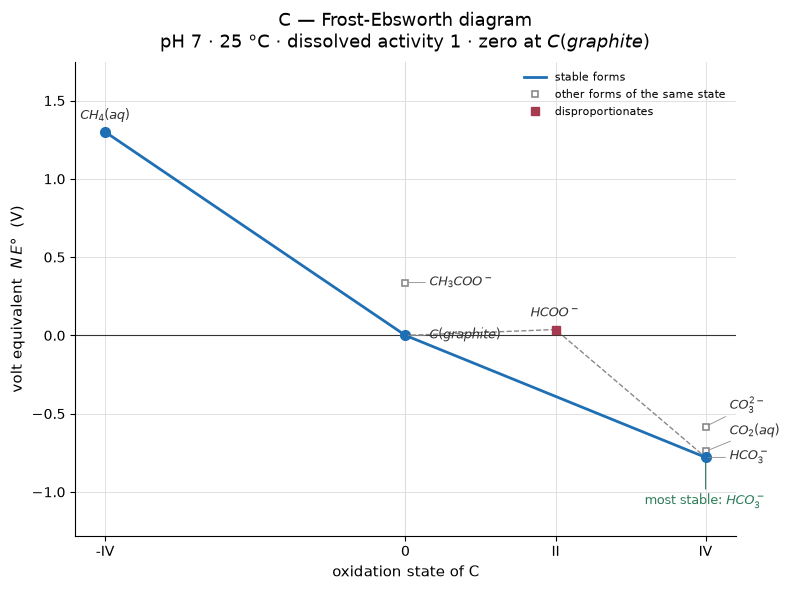

In [10]:
plot_frost("C", pH=7.0, predominant_only=False, label="all")
plt.show()

Two options control what is drawn, and they are independent:

* `show="all"` or `show="predominant"` — which points get a marker.
* `label="all"` or `label="predominant"` — which of them get named.

The default is `show="all", label="predominant"`, which keeps the figure
readable while hiding nothing. Compare:

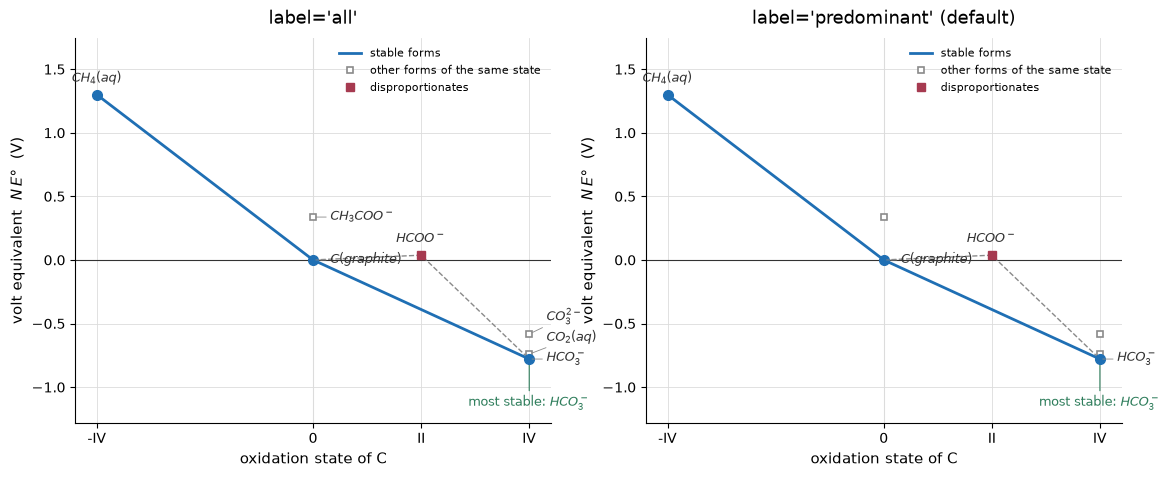

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
plot_frost("C", pH=7.0, predominant_only=False, label="all", ax=axes[0], title="label='all'")
plot_frost("C", pH=7.0, predominant_only=False, ax=axes[1], title="label='predominant' (default)")
plt.show()

**Predominant and stable are different words for different things**, and
the open grey markers are where the difference shows.

*Predominant* is a comparison **within** one oxidation state — which of the
three carbonate forms, decided entirely by pH. *Stable* is a comparison
**across** states — whether that carbonate survives at all, decided by the
convex hull. An open grey square is a species that is neither: a real form
of its state that some other form of the same state outcompetes at this pH.
It is not falling apart, so it is not drawn in red.

The distinction has teeth. Ask for the acetate/graphite pair directly:

In [12]:
by_name = {point.backend: point for point in everything.points}
for name in ("Graphite", "Acetate"):
    point = by_name[name]
    print(f"{name:10s} volt equivalent {point.volt_equivalent:+.3f} V, "
          f"ΔG {point.gibbs:+7.1f} kJ per mol C")

difference = by_name["Acetate"].gibbs - by_name["Graphite"].gibbs
print(f"\nacetate minus graphite: {difference:+.1f} kJ per mol C")

Graphite   volt equivalent +0.000 V, ΔG    +0.0 kJ per mol C
Acetate    volt equivalent +0.337 V, ΔG   +32.5 kJ per mol C

acetate minus graphite: +32.5 kJ per mol C


That difference is a real free energy and it is **not** a potential. Both
species are C(0), so converting one into the other transfers *no* electrons,
and `E = ΔG/nF` would divide by zero. The library refuses rather than
printing something:

In [13]:
try:
    everything.slope("Acetate", "Graphite")
except ValueError as exc:
    print("refused:", exc)

refused: Acetate and Graphite are the same oxidation state


So: distances **across** the diagram are potentials, distances **up and
down within one oxidation state** are free energies, and the two are not
interchangeable. That is worth saying out loud, because a Frost diagram
invites you to read every gap as a voltage.

## Where each form lives

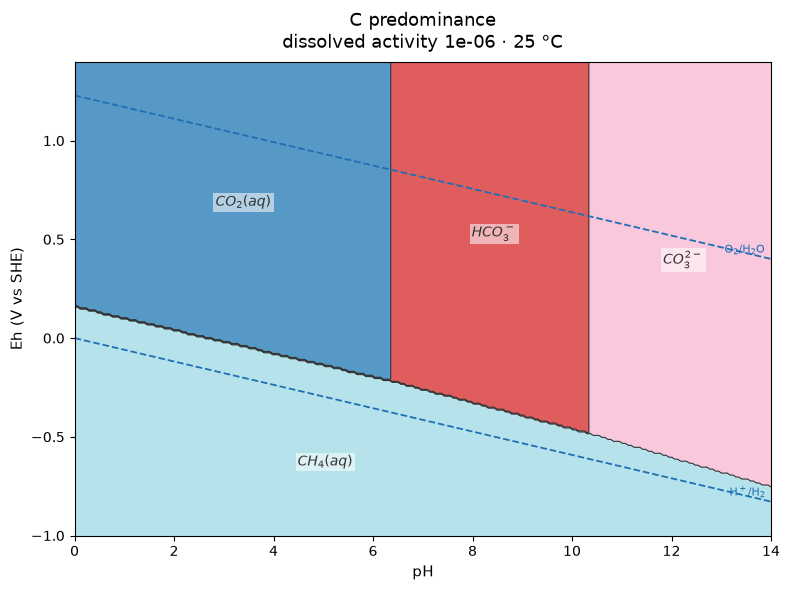

In [14]:
plot_pourbaix("C", figsize=(8.0, 6.0))
plt.show()

The carbonate boundaries are vertical, because they are acid–base equilibria
and do not involve electrons at all; the methane boundary slopes, because it
does. The dashed lines are the stability limits of water, computed from this
library's own couples.

## Who lives on each step

In [15]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
carbon = [
    "hydrogenotrophic_methanogenesis",
    "acetoclastic_methanogenesis",
    "acetogenesis",
    "aerobic_acetate_oxidation",
    "aerobic_methanotrophy",
    "anaerobic_methane_oxidation",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[carbon][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
hydrogenotrophic_methanogenesis,Hydrogenotrophic methanogenesis,-15.354234,H2(g) + 1/4 CO2(aq) -> 1/4 Methane(aq) + 1/2 H2O
acetoclastic_methanogenesis,Acetoclastic methanogenesis,-1.393414,1/4 Acetate + 1/4 H+ -> 1/4 CO2(aq) + 1/4 Meth...
acetogenesis,Homoacetogenesis from H2 and CO2,-13.960820,H2(g) + 1/2 CO2(aq) -> 1/4 H+ + 1/4 Acetate + ...
aerobic_acetate_oxidation,Aerobic acetate oxidation,-108.764268,1/4 Acetate + 1/4 H+ + 1/2 O2(aq) -> 1/2 CO2(a...
aerobic_methanotrophy,Aerobic methanotrophy,-107.370854,1/4 Methane(aq) + 1/2 O2(aq) -> 1/4 CO2(aq) + ...
anaerobic_methane_oxidation,Anaerobic oxidation of methane with sulfate,-3.687292,1/4 Methane(aq) + 1/4 H+ + 1/4 SO4-- -> 1/4 CO...


Read that against the ladder. CO₂ → CH₄ is the bottom two steps run
backwards, and it pays about as badly as anything a cell does — which is why
methanogens are slow, live at the end of the electron chain, and are the
organisms most often found sitting within a few kJ of the thermodynamic
limit. Aerobic acetate oxidation runs the same carbon uphill in the other
direction against oxygen and pays roughly twenty times better.

## One thing worth taking away

The nominal oxidation state of carbon in an organic molecule is the single
most useful number about it, and the library computes it directly:

In [16]:
for name in ("Methane(aq)", "Acetate", "Formate(aq)", "HCO3-"):
    formula = mt.resolve(name).formula
    state = mt.mean_oxidation_state("C", formula)
    # An exact Fraction, not a float: acetate is 0 and the C(0) rung means it.
    print(f"{name:14s} {formula:8s}  mean C oxidation state {float(state):+.2f}  ({state})")

Methane(aq)    CH4       mean C oxidation state -4.00  (-4)
Acetate        C2H3O2-   mean C oxidation state +0.00  (0)
Formate(aq)    CHO2-     mean C oxidation state +2.00  (2)
HCO3-          HCO3-     mean C oxidation state +4.00  (4)


That is the x axis of the Frost diagram. A substrate's position on it tells
you how many electrons it has to give, and the Frost curve tells you what
they are worth.